In [1]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("beer.csv")

# Show first rows
df.head()

,name,calories,sodium,alcohol,cost
0,Budweiser,144,15,4.7,0.43
1,Schlitz,151,19,4.9,0.43
2,Lowenbrau,157,15,0.9,0.48
3,Kronenbourg,170,7,5.2,0.73
4,Heineken,152,11,5.0,0.77


In [3]:
df.columns

Index(['name', 'calories', 'sodium', 'alcohol', 'cost'], dtype='str')

In [5]:
df = pd.DataFrame({
    "text": ["Hello 123!", "Clean THIS text!!", "More 999 data"]
})

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

texts = [
    "I love this movie!!!",
    "Terrible product... would not buy again",
    "Okay experience, nothing special"
]

texts_clean = [re.sub(r'[^a-z\s]', '', t.lower()) for t in texts]

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(texts_clean)

print(texts_clean)
print(X.shape)

['i love this movie', 'terrible product would not buy again', 'okay experience nothing special']
(3, 8)


In [11]:
print(X.shape)

(3, 8)


In [12]:
df.head()

,text
0,Hello 123!
1,Clean THIS text!!
2,More 999 data


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# your documents (replace with your real data)
documents = [
    "text one example",
    "text two example",
    "another document text",
    "more sample data here"
]

# Step 1: Vectorize text
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

# Step 2: Fit KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

# Step 3: Get feature names
terms = vectorizer.get_feature_names_out()

# Step 4: Sort cluster centers
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

# Step 5: Print top words per cluster
for i in range(k):
    print(f"\nCluster {i} top words:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(top_words)


Cluster 0 top words:
['example', 'text', 'sample', 'document', 'data']

Cluster 1 top words:
['sample', 'data', 'text', 'example', 'document']

Cluster 2 top words:
['document', 'text', 'sample', 'example', 'data']


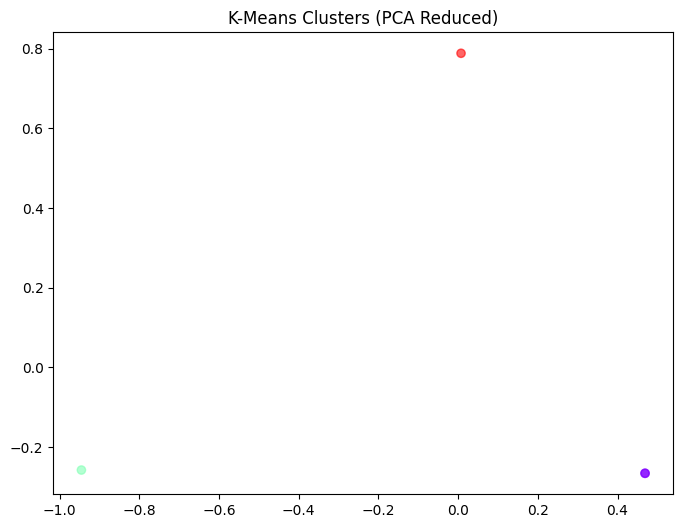

In [16]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_dense = X.toarray()

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_dense)

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_dense)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='rainbow', alpha=0.6)
plt.title("K-Means Clusters (PCA Reduced)")
plt.show()

In [19]:
print(df.shape)
print(X.shape)
print(kmeans.labels_[:10])

(3, 1)
(4, 5)
[0 0 2 1]
